<a href="https://colab.research.google.com/github/niruinso/django/blob/main/Algebra.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Проверка числа на простоту

In [ ]:
def isPrime(n):
    i = 2
    flag = True
    while(i * i <= abs(n)):
        if n % i == 0:
            return False
        i += 1
    return True


In [ ]:
print(isPrime(5))
print(isPrime(105))
print(isPrime(-2))
print(isPrime(225))
print(isPrime(-171))

True
False
True
False
False


## Решето Эратосфена

In [ ]:
def Eratosthenes(n):
    if(n < 2):
        raise Exception(f"n must be more than 2, got {n}")
    arr = [i for i in range(2, n+1)]
    for el in arr:
        if(el == 0):
            continue
        print(str(el) + " ")
        i = 2
        while((el * i - 2) < len(arr)):
            arr[el*i-2] = 0
            i += 1

In [ ]:
Eratosthenes(100)

2 
3 
5 
7 
11 
13 
17 
19 
23 
29 
31 
37 
41 
43 
47 
53 
59 
61 
67 
71 
73 
79 
83 
89 
97 


In [ ]:
Eratosthenes(2)

2 


## Разложение числа на простые

In [ ]:
def factorize(n):
    if(isPrime(n)):
        return str(n)
    if(n < 0):
        return f"-({factorize(-n)})"
    i = 2
    while(i * i <= n):
        if(n % i == 0):
            return f"{str(i)}*{factorize(n // i)}"
        i += 1
    return str(n)

In [ ]:
print(f"25 = {factorize(25)}")
print(f"1 = {factorize(1)}")
print(f"-27 = {factorize(-27)}")
print(f"17 = {factorize(17)}")
print(f"1984 = {factorize(1984)}")

25 = 5*5
1 = 1
-27 = -(3*3*3)
17 = 17
1984 = 2*2*2*2*2*2*31


## Евклид (НОД)

In [ ]:
def myGCD(a, b):
    if(a < 0 or b < 0):
        return myGCD(abs(a), abs(b))
    if(b == 0):
        return a
    return myGCD(b, a % b)

In [ ]:
print(myGCD(-15, 35))

5


In [ ]:
def gcdExtended(a, b):
    if b == 0:
        return a, 1, 0

    gcd, x1, y1 = gcdExtended(b, a % b)
    #a=bq+r
    #r=a-bq
    #d=bx+ry=bx+(a-bq)y=a*y+b*(x-yq)
    x = y1
    y = x1 - y1 *(a // b)
    return gcd, x, y

In [ ]:
gcdExtended(11, 15)

(1, -4, 3)

In [ ]:
def myLCM(a, b):
    return abs(a * b) // myGCD(a, b)

In [ ]:
myLCM(15, 35)

105

## Быстрое возведение в степень

In [ ]:
def myPow(x, deg):
    if(deg < 0):
        return myPow(1/x, -deg)
    if(deg == 0):
        return 1
    return x * myPow(x, deg-1)

In [ ]:
def fastPow(x, deg):
    if(deg<0):
        return fastPow(1/x, -deg)
    if(deg==0):
        return 1
    if(deg%2==0):
        return fastPow(x*x, deg/2)
    return x * fastPow(x*x, (deg-1)/2)

In [ ]:
%%time
myPow(2, 100)

CPU times: user 53 µs, sys: 9 µs, total: 62 µs
Wall time: 66.5 µs


1267650600228229401496703205376

In [ ]:
%%time
fastPow(2, 100)

CPU times: user 19 µs, sys: 0 ns, total: 19 µs
Wall time: 22.6 µs


1267650600228229401496703205376

In [ ]:
fastPow(2, 192)

6277101735386680763835789423207666416102355444464034512896

In [ ]:
%%time
import sys
sys.set_int_max_str_digits(100000000)

fastPow(2, 100000)

CPU times: user 1.06 ms, sys: 12 µs, total: 1.08 ms
Wall time: 1.09 ms


...

## Решение системы линейных сравнений

In [ ]:
def solution(a, b, n):
    gcd = myGCD(a, n)
    if(b % gcd != 0):
        print(f"Решений сравнения {a}x={b}(mod{n}) нет")
        return
    a1 = a/gcd
    b1 = b/gcd
    n1 = n/gcd
    d, u, v = gcdExtended(a1, n1)
    print(f"Решение сравнения {a}x={b}(mod{n}) лежит в классе вычетов {(b1*u)%n1} по модулю n={n1}")

In [ ]:
solution(2, 3, 4)

Решений сравнения 2x=3(mod4) нет


In [ ]:
solution(6, 4, 10)

Решение сравнения 6x=4(mod10) лежит в классе вычетов 4.0 по модулю n=5.0


## Функция Эйлера для натурального n

In [ ]:
from collections import Counter

def EulerFunc(n):
    if n == 1:
        return 1
    primes = factorize(n).split('*')
    res = 1
    counter = Counter(primes)
    for prime, exponent in counter.items():
        res *= (int(prime) ** (exponent - 1)) * (int(prime) - 1)
    return res

In [ ]:
EulerFunc(11)

10

In [ ]:
EulerFunc(48)

16

## Вычисление остатка от деления... при помощи теоремы Эйлера

In [ ]:
def FastMod(a, exp, n):
    if myGCD(a, n) != 1:
        return fastPow(a, exp) % n
    eulerNum = EulerFunc(n)
    newExp = exp % eulerNum
    return fastPow(a, newExp) % n

In [ ]:
FastMod(5, 130, 48)

25

In [ ]:
FastMod(1380, 1945, 19)

12

## Мультипликативное обратное по модулю n

In [ ]:
def reversedMult(a, n):
    gcd, u, v = gcdExtended(a, n)
    if(gcd != 1):
        raise Exception(f"gcd({a}, {n}) = {gcd}, not 1, there is no reversed mult")
    return u

In [ ]:
reversedMult(3, 5)

2

In [ ]:
reversedMult(7, 10)

3

## КТО

In [ ]:
from functools import reduce

def KTO(arr_mods, arr_coefs):
    res = 0
    n = reduce(lambda x, y: x*y, arr_mods)
    for ind in range(len(arr_mods)):
        m_j = n / arr_mods[ind]
        m_j_reversed = reversedMult(m_j, arr_mods[ind])
        res += arr_coefs[ind] * m_j * m_j_reversed
    return res % n

In [ ]:
KTO([5, 7, 11], [2, 3, 4])

367.0

# 1)Деление полиномов над целостным кольцом Z2 = {0, 1}

### Для нашего кольца 1 ненулевой элемент - 1, его обратное - 1.

In [ ]:
def reversive(b_m):
  return b_m

### Правило определения вычитания одного элемента из другого (когда столбиком делим)

In [ ]:
def rule(coef, a, b):
  return (a - b * coef) % 2

In [ ]:
def poly_division(f, g):
  while(len(f) > 0 and f[0] == 0):
    f.pop(0)
  if(len(f) == 0):
    return [0], [0]
  while(len(g) > 0 and g[0] == 0):
    g.pop(0)
  if(len(g) == 0):
    raise Exception("Divide by zero")

  q = []
  r = []

  f_copy = [el for el in f]

  while(True):
    if (len(f_copy) == 1 and len(g) == 1):
      q.append(f_copy[0] * reversive(g[0]))
      r = [0]
      break
    if len(f_copy) < len(g):
      r = f_copy
      break

    coef = f_copy[0] * reversive(g[0])
    for i in range(len(g)):
      f_copy[i] = rule(coef, f_copy[i], g[i])

    q.append(coef)
    f_copy.pop(0)
  return q, r


In [ ]:
def poly_mult(f, g, p=2):
    result = [0] * (len(f) + len(g) - 1)
    for i in range(len(f)):
        for j in range(len(g)):
            result[i + j] = (result[i + j] + f[i] * g[j]) % p
    return result

In [ ]:
def show_res(f, g, q, r):
  n = len(f) - 1
  m = len(g) - 1
  len_q = len(q) - 1
  len_r = len(r) - 1

  for i in range(n, 0, -1):
    if f[n-i] == 0:
      continue
    print(f"{f[n - i]}*x^{i}", end = ' + ')
  if f[n] == 0:
    print(" = (")
  else:
    print(f"{f[n]} = (", end = "")

  for i in range(len_q, 0, -1):
    if q[len_q - i] == 0:
      continue
    print(f"{q[len_q - i]}*x^{i}", end = ' + ')

  print(f"{q[len_q]}) * (", end = "")

  for i in range(m, 0, -1):
    if g[m - i] == 0:
      continue
    print(f"{g[m - i]}*x^{i}", end = ' + ')

  print(f"{g[m]}) + ", end = "")

  for i in range(len_r, 0, -1):
    if r[len_r - i] == 0:
      continue
    print(f"{r[len_r - i]}*x^{i}", end = ' + ')
  print(r[len_r])


## x^4 + x^2 + x + 1 / x^2 + 1

In [ ]:
f = [1, 0, 1, 1, 1]
g = [1, 0, 1]
q, r = poly_division(f, g)
show_res(f, g, q, r)

1*x^4 + 1*x^2 + 1*x^1 + 1 = (1*x^2 + 0) * (1*x^2 + 1) + 1*x^1 + 1


## x^5 + x^4 + x^3 + x^2 + x + 1 / x^2 + 1

In [ ]:
f = [1, 1, 1, 1, 1, 1]
g = [1, 0, 1]
q, r = poly_division(f, g)
show_res(f, g, q, r)

1*x^5 + 1*x^4 + 1*x^3 + 1*x^2 + 1*x^1 + 1 = (1*x^3 + 1*x^2 + 0) * (1*x^2 + 1) + 1*x^1 + 1


### All Right!)

# 2)Вычисления в простых конечных полях (произведение и возведение в степень через битовые операции).

In [ ]:
BITS = 32
MASK = (1 << BITS) - 1

def add(a, b):
    while b != 0:
        carry = (a & b) & MASK
        a = (a ^ b) & MASK
        b = (carry << 1) & MASK
    return a

In [ ]:
add(2, 5)

7

In [ ]:
add(1002, 5005)

6007

## Умножение. На каждой итерации множимое сдвигаем влево, а множитель - вправо. Если в множителе младший член - 1, к результату прибавляем множимое.

In [ ]:
def mult(a, b, p):
  res = 0
  while(b != 0):
    if b & 1:
      res = add(res, a)
    a = a << 1
    b = b >> 1
  neg_p = add(~p, 1)
  while res > p:
    res = add(res, neg_p)
  return res

In [ ]:
mult(2, 4, 7)

1

In [ ]:
mult(33, 16, 17)

1

## Возведение в степень. Представляем а в степени deg как умножение a в степенях, в сумме дающих deg и являющихся степенями двойки (13 = 1 + 4 + 8), другими словами, на каждой итерации возводим а в квадрат и делаем сдвиг deg и смотрим на младший член

In [ ]:
def bitwise_pow(a, deg, p):
  res = 1
  neg_p = add(~p, 1)
  while a > p:
    res = add(res, neg_p)

  while deg != 0:
    if deg & 1:
      res = mult(res, a, p)

    a = mult(a, a, p)
    deg = deg >> 1
  return res

In [ ]:
bitwise_pow(2, 5, 7)

4

In [ ]:
bitwise_pow(3, 5, 5)

3

# 4) Нахождение неприводимых полиномов в конечном поле.

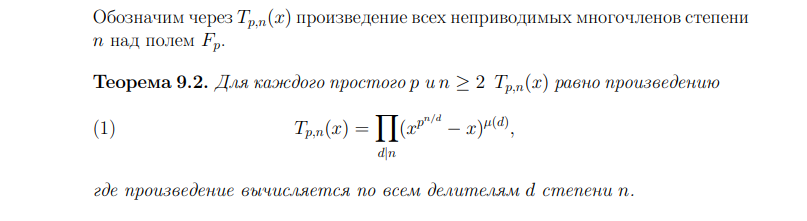

In [ ]:
from collections import Counter

def Mobius(n):
    if n == 1:
        return 1
    res = 1
    primes = factorize(n).split('*')
    counter = Counter(primes)
    for prime, exponent in counter.items():
        if exponent > 1:
          res = 0
          break
        res *= -1
    return res

## Функция возвращает полином x^k - x над GF(p)

In [ ]:
def poly_xk_minus_x(k, p=2):
    poly = [0] * (k + 1)
    poly[0] = 1
    poly[-2] =1

    return poly

In [ ]:
def compute_Tpn(n, p=2):
    result_mult = [1]
    result_div = [1]

    for d in range(1, n + 1):
        if n % d == 0:
          mu = Mobius(d)

          if mu == 0:
              continue

          exp = p ** (n // d)
          poly = poly_xk_minus_x(exp, p)

          if mu == 1:
              result_mult = poly_mult(result_mult, poly, p)
          else:
              result_div = poly_mult(result_div, poly, p)
    res, _ = poly_division(result_mult, result_div)
    return res


## Перевод числа в систему счисления с основанием base

In [ ]:
def to_base(n, base):
    digits = []
    while n > 0:
        digits.append(n % base)
        n //= base
    return digits[::-1]

## Нахождение неприводимых полиномов

In [ ]:
def find_irreducible_factor(p, n):
  T = compute_Tpn(n, p)
  res = []

  for el in range(p ** n, p ** (n + 1)):
    polynom = to_base(el, p)
    q, r = poly_division(T, polynom)
    if all(x == 0 for x in r):
      res.append(polynom)
  return res


## При реализации используется poly_division - деление над полем {0, 1}. Поэтому алгоритм работает только для этого поля. Для других полей надо переписать poly_division (изменить rule - вычисление обратного)

In [ ]:
irr = find_irreducible_factor(2, 8)
irr

[[1, 0, 0, 0, 1, 1, 0, 1, 1],
 [1, 0, 0, 0, 1, 1, 1, 0, 1],
 [1, 0, 0, 1, 0, 1, 0, 1, 1],
 [1, 0, 0, 1, 0, 1, 1, 0, 1],
 [1, 0, 0, 1, 1, 1, 0, 0, 1],
 [1, 0, 0, 1, 1, 1, 1, 1, 1],
 [1, 0, 1, 0, 0, 1, 1, 0, 1],
 [1, 0, 1, 0, 1, 1, 1, 1, 1],
 [1, 0, 1, 1, 0, 0, 0, 1, 1],
 [1, 0, 1, 1, 0, 0, 1, 0, 1],
 [1, 0, 1, 1, 0, 1, 0, 0, 1],
 [1, 0, 1, 1, 1, 0, 0, 0, 1],
 [1, 0, 1, 1, 1, 0, 1, 1, 1],
 [1, 0, 1, 1, 1, 1, 0, 1, 1],
 [1, 1, 0, 0, 0, 0, 1, 1, 1],
 [1, 1, 0, 0, 0, 1, 0, 1, 1],
 [1, 1, 0, 0, 0, 1, 1, 0, 1],
 [1, 1, 0, 0, 1, 1, 1, 1, 1],
 [1, 1, 0, 1, 0, 0, 0, 1, 1],
 [1, 1, 0, 1, 0, 1, 0, 0, 1],
 [1, 1, 0, 1, 1, 0, 0, 0, 1],
 [1, 1, 0, 1, 1, 1, 1, 0, 1],
 [1, 1, 1, 0, 0, 0, 0, 1, 1],
 [1, 1, 1, 0, 0, 1, 1, 1, 1],
 [1, 1, 1, 0, 1, 0, 1, 1, 1],
 [1, 1, 1, 0, 1, 1, 1, 0, 1],
 [1, 1, 1, 1, 0, 0, 1, 1, 1],
 [1, 1, 1, 1, 1, 0, 0, 1, 1],
 [1, 1, 1, 1, 1, 0, 1, 0, 1],
 [1, 1, 1, 1, 1, 1, 0, 0, 1]]

## 3) Построить поле GF(256).

In [ ]:
def to_poly(irr):
  l = len(irr)
  res = 0
  for i in range(l):
    res += irr[i] * 2 ** (l - 1 - i)
  return res

In [ ]:
to_poly(irr[1])

285

In [ ]:
class GF256:
  IRREDUCIBLE = to_poly(irr[1])
  p = 2
  n = 8

  @staticmethod
  def add(a, b):
    return a ^ b

  @staticmethod
  def sub(a, b):
    return a ^ b

  @staticmethod
  def one():
    return 1

  @staticmethod
  def zero():
    return 0

  @staticmethod
  def mult(a, b):
    res = 0
    while b != 0:
      if b & 1:
        res ^= a
      a = (a << 1) ^ (GF256.IRREDUCIBLE if (a & 128) else 0)
      b = b >> 1

    return res & 255

  @staticmethod
  def pow(a, deg):
    res = 1

    while deg != 0:
      if deg & 1:
        res = GF256.mult(res, a)

      a = GF256.mult(a, a)
      deg = deg >> 1
    return res

  @staticmethod
  def inverse(a):
    if a == 0:
      raise Exception("No inverse for zero")
    return GF256.pow(a, 254)

  @staticmethod
  def divide(a, b):
    if b == 0:
      raise Exception("Division by zero")
    if a == 0:
      return 0
    return GF256.mult(a, GF256.inverse(b))

  @staticmethod
  def to_poly(a):
      if a == 0:
          return "0"
      terms = []
      for i in range(7, -1, -1):
          if a & (1 << i):
              if i == 0:
                  terms.append("1")
              elif i == 1:
                  terms.append("x")
              else:
                  terms.append(f"x^{i}")
      return " + ".join(terms)

# 5) Решение алгебраических уравнений второй степени в конечных полях (ax^2 + bx + c = 0

In [ ]:
def solve_p2(a, b, c, gf=GF256):
  #ax^2 + bx + c = 0 -> x^2 + (b/a)x + (c/a) = 0
  B = gf.divide(b, a)
  C = gf.divide(c, a)

  if B == 0:
    return [gf.pow(C, 2 ** (gf.n - 1))]

  #x = B*t -> t^2 + t = D
  D = gf.divide(C, gf.mult(B, B))

  F = [[0] * gf.n for _ in range(gf.n)]
  for i in range(gf.n):
    basis_elem = 1 << i
    sq_basis = gf.mult(basis_elem, basis_elem)

    for j in range(gf.n):
            if sq_basis & (1 << j):
                F[j][i] = 1

  M = [[0] * gf.n for _ in range(gf.n)]
  I = [[1 if i == j else 0 for j in range(gf.n)] for i in range(gf.n)]

  for i in range(gf.n):
      for j in range(gf.n):
          M[i][j] = F[i][j] ^ I[i][j]

  #M*t=D
  rhs = [(D >> i) & 1 for i in range(gf.n)]
  tmp = [M[i][:] + [rhs[i]] for i in range(gf.n)]

  #Gauss
  for col in range(gf.n):
      pivot = -1
      for row in range(col, gf.n):
          if tmp[row][col] == 1:
              pivot = row
              break

      if pivot == -1:
          continue

      tmp[col], tmp[pivot] = tmp[pivot], tmp[col]

      for row in range(gf.n):
          if row != col and tmp[row][col] == 1:
              for j in range(col, gf.n + 1):
                  tmp[row][j] ^= tmp[col][j]

  for row in range(gf.n):
    if all(tmp[row][j] == 0 for j in range(gf.n)) and tmp[row][gf.n] == 1:
        return []

  t1_vec = [0] * gf.n
  for i in range(gf.n):
      pivot_col = -1
      for j in range(gf.n):
          if tmp[i][j] == 1:
              pivot_col = j
              break

      if pivot_col != -1:
          t1_vec[pivot_col] = tmp[i][gf.n]

  #t2=t1+1
  one = [1] + [0] * (gf.n - 1)
  t2_vec = [t1_vec[i] ^ one[i] for i in range(gf.n)]

  t1 = 0
  t2 = 0
  for i in range(gf.n):
      if t1_vec[i]:
          t1 |= (1 << i)
      if t2_vec[i]:
          t2 |= (1 << i)

  x1 = gf.mult(t1, B)
  x2 = gf.mult(t2, B)

  if x1 == x2:
      return [x1]
  else:
      return [x1, x2]

In [ ]:
import random

def random_nonzero(p, n):
  while True:
    coeffs = [random.randint(0, p - 1) for _ in range(n)]
    if any(c != 0 for c in coeffs):
        return coeffs

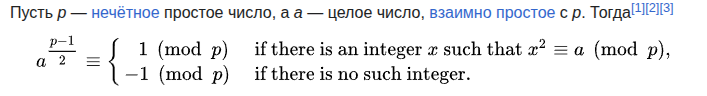

In [ ]:
def solve_not_p2(a, b, c, gf):
  #ax^2 + bx + c = 0 -> x^2 + (b/a)x + (c/a) = 0
  B = gf.divide(b, a)
  C = gf.divide(c, a)
  # y = x + (B/2) -> y^2 = (B/2)^2 - C = D
  D = gf.sub(gf.pow(gf.divide(B, gf.add(gf.one(), gf.one())), gf.add(gf.one(), gf.one())), C)
  if gf.zero() == D:
    return [gf.sub(gf.zero(), gf.divide(B, gf.add(gf.one(), gf.one())))]

  q = gf.p ** gf.n
  exp_check = (q - 1) // 2
  if gf.pow(D, exp_check) != gf.one():
    return []

  Q = q - 1
  s = 0
  while Q % 2 == 0:
    Q //= 2
    s += 1

  z = random_nonzero(gf.p, gf.n)
  minus_one = gf.sub(gf.zero(), gf.one())
  # Находим невычет
  while gf.pow(z, exp_check) != minus_one:
    z = random_nonzero(gf.p, gf.n)
  # Генератор второй подгруппы (база)
  c_elem = gf.pow(z, Q)
  # Начальное приближение корня
  y = gf.pow(D, (Q + 1) // 2)
  # Индикатор ошибки
  t = gf.pow(D, Q)
  # Текущая степень двойки
  m = s
  one = gf.one()
  while t != one:
    i = 1
    temp = gf.pow(t, 2)
    while temp != one:
      temp = gf.pow(temp, 2)
      i += 1

    exponent = 1 << (m - i - 1)
    b = gf.pow(c_elem, exponent)
    y = gf.mult(y, b)
    t = gf.mult(t, gf.mult(b, b))
    c_elem = gf.mult(b, b)
    m = i

  x1 = gf.sub(y, gf.divide(B, gf.add(gf.one(), gf.one())))
  x2 = gf.sub(gf.sub(gf.zero(), y), gf.divide(B, gf.add(gf.one(), gf.one())))

  return [x1, x2]

In [ ]:
def solve_quadratic(a, b, c, gf):
  if gf.p == 2:
    return solve_p2(a, b, c, gf)
  return solve_not_p2(a, b, c, gf)

In [ ]:
class GF7:
    p = 7
    n = 1

    @staticmethod
    def zero():
        return 0

    @staticmethod
    def one():
        return 1

    @staticmethod
    def add(a, b):
        return (a + b) % 7

    @staticmethod
    def sub(a, b):
        return (a - b) % 7

    @staticmethod
    def mult(a, b):
        return (a * b) % 7

    @staticmethod
    def pow(base, exp):
        if isinstance(base, list):
          base = base[0]
        if exp == 0:
            return 1
        if exp < 0:
            base = GF7.divide(1, base)
            exp = -exp
        result = 1
        base = base % 7
        while exp > 0:
            if exp & 1:
                result = (result * base) % 7
            base = (base * base) % 7
            exp >>= 1
        return result

    @staticmethod
    def divide(a, b):
        if b == 0:
            raise ZeroDivisionError("Деление на ноль в GF(7)")
        # Обратный элемент через малую теорему Ферма: b^(p-2)
        inv_b = GF7.pow(b, 5)  # 7-2 = 5
        return (a * inv_b) % 7

## x^2 + 3x + 2 = 0
## 5\*5 + 3\*5 + 2 = 42 = 0 (mod(7))
## 6\*6 + 3\*6 + 2 = 56 = 0 (mod 7)
## Ans: 5, 6

In [ ]:
solve_quadratic(1, 3, 2, GF7)

[6, 5]

## x^2 + 4x + 4
## D = 16 - 16 = 0 -> 1 solution
## 5\*5 + 4\*5 + 4 = 49 = 0 (mod 7)

In [ ]:
solve_quadratic(1, 4, 4, GF7)

[5]

## x^2 + 4x + 5

In [ ]:
solve_quadratic(1, 4, 5, GF7)

[]

In [ ]:
class GF49:
    p = 7
    n = 2

    @staticmethod
    def zero():
        return [0, 0]

    @staticmethod
    def one():
        return [1, 0]

    @staticmethod
    def add(a, b):
        if isinstance(a, int): a = [a, 0]
        if isinstance(b, int): b = [b, 0]
        return [(a[0] + b[0]) % 7, (a[1] + b[1]) % 7]
    @staticmethod
    def sub(a, b):
        if isinstance(a, int): a = [a, 0]
        if isinstance(b, int): b = [b, 0]
        return [(a[0] - b[0]) % 7, (a[1] - b[1]) % 7]

    @staticmethod
    def mult(a, b):
        if isinstance(a, int): a = [a, 0]
        if isinstance(b, int): b = [b, 0]

        c0 = (a[0] * b[0] + 3 * a[1] * b[1]) % 7
        c1 = (a[0] * b[1] + a[1] * b[0]) % 7

        return [c0, c1]

    @staticmethod
    def pow(base, exp):
        if isinstance(base, int):
            base = [base, 0]

        if isinstance(exp, list):
            if exp[1] == 0:
                exp = exp[0]
            else:
                raise TypeError(f"Степень должна быть целым числом, не {exp}")

        if exp == 0:
            return GF49.one()

        if exp < 0:
            base = GF49.inverse(base)
            exp = -exp

        result = GF49.one()
        while exp > 0:
            if exp & 1:
                result = GF49.mult(result, base)
            base = GF49.mult(base, base)
            exp >>= 1
        return result

    @staticmethod
    def inverse(elem):
        if isinstance(elem, int):
            elem = [elem, 0]

        a, b = elem

        norm = (a*a - 3*b*b) % 7

        if norm == 0:
            raise ZeroDivisionError(f"Нулевая норма для {elem}")

        inv_norm = pow(norm, 5, 7)

        result0 = (a * inv_norm) % 7
        result1 = (-b * inv_norm) % 7

        return [result0, result1]

    @staticmethod
    def divide(a, b):
        if isinstance(a, int): a = [a, 0]
        if isinstance(b, int): b = [b, 0]

        inv_b = GF49.inverse(b)
        return GF49.mult(a, inv_b)

    @staticmethod
    def eq(a, b):
        if isinstance(a, int): a = [a, 0]
        if isinstance(b, int): b = [b, 0]
        return a[0] == b[0] and a[1] == b[1]

    @staticmethod
    def element_to_str(elem):
        if isinstance(elem, int): elem = [elem, 0]
        if elem[0] == 0 and elem[1] == 0:
            return "0"
        elif elem[1] == 0:
            return str(elem[0])
        elif elem[0] == 0:
            return "α" if elem[1] == 1 else f"{elem[1]}α"
        else:
            return f"{elem[0]}+{elem[1]}α" if elem[1] != 1 else f"{elem[0]}+α"

## x^2 + 2(1+2α)x + (1+2α)^2 = 0
## D = 0, Ans = 6+5α
## (6+5α)^2 + 2(1+2α)*(6+5α) + (1+2α)^2 = 36 + 60α + 25α^2 + 12 + 34α + 20α^2 + 1 + 4α + 4α^2 = 49 + 98α + 49α^2 = 0 (mod7)

In [ ]:
r = [1, 2]  # 1+2α
two = [2, 0]
a = [1, 0]
b = GF49.mult(two, r)
c = GF49.mult(r, r)
solve_quadratic(a, b, c, GF49)

[[6, 5]]

## x^2 + (α^2)x + (α^2+1) = 0
## 1 + α^2 + α + 1 = 2α^2 + 2 = 0 -> x = 1
## (α^2 + 1)^2 + (α^2)(α^2+1) + (α^2+1) = α^4 + 1 + α^4 + α^2 _ α^2 + 1 = 2α^4  + 2α^2 + 2 = 0 -> x = α^2 + 1

In [ ]:
ans = solve_quadratic(1,4,5,GF256)
print(GF256.to_poly(ans[0]), GF256.to_poly(ans[1]), sep = '; ')

x^2 + 1; 1
